# Modelos

> Modelo base : Naive estacional

> Modelo experimentos : SARIMA

In [12]:
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error as mape, root_mean_squared_error as rmse
from statsforecast.models import ARIMA
from statsforecast import StatsForecast

import sys
sys.path.append('..')

from utils.estacionariedad import prueba_diferenciacion
from utils.parametros_ARIMA import pacf_acf

In [2]:
df = pd.read_csv('../datos/df_01.csv',
                parse_dates = ['fecha'])
df.head()

,fecha,value
0,2019-01-01 00:00:00,23216.0
1,2019-01-01 01:00:00,24947.0
2,2019-01-01 02:00:00,27655.0
3,2019-01-01 03:00:00,27676.0
4,2019-01-01 04:00:00,26853.0


### Modelo Seasonal Naive

In [3]:
H = 24
df_train = df.iloc[:-H]['value'].copy()
df_test = df.iloc[-H]['value'].copy()

df_pred = df_train.shift(H)

mape_base = mape(df_train[H:], df_pred[H:])
rmse_base = rmse(df_train[H:], df_pred[H:])

print('> Medidas desempeño --- Seasonal Naive')
print(f'MAPE: {100*mape_base:.4f}')
print(f'RMSE: {rmse_base:.4f}')

> Medidas desempeño --- Seasonal Naive
MAPE: 5.0687
RMSE: 1821.9338


### Modelo SARIMA
* Una sola variable
* Tendencia y varianza constantes
* Serie estacionaria (?)

Prueba de estacionariedad

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
La serie presenta un patrón estacional


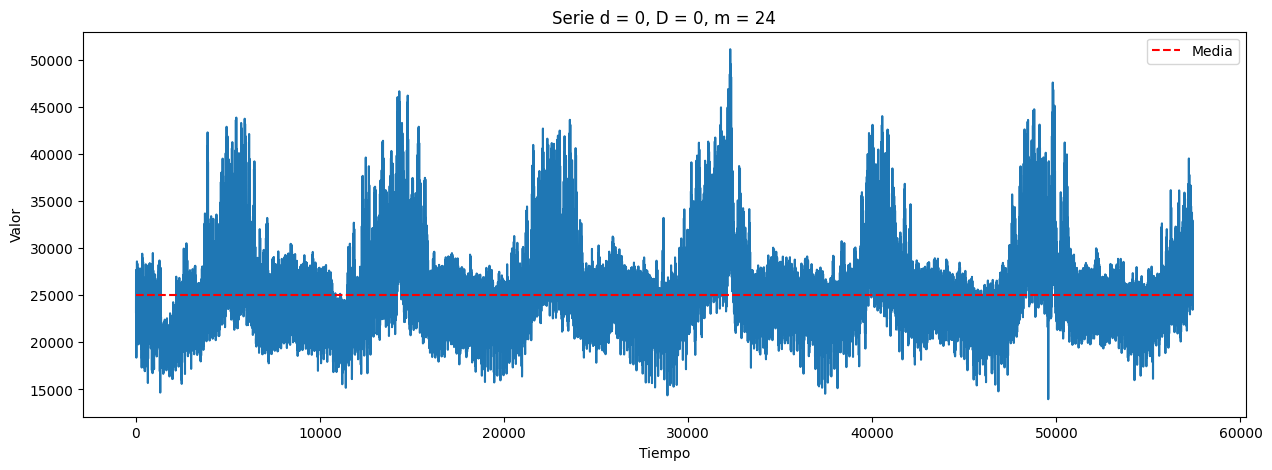

In [4]:
prueba_diferenciacion(df['value'], d=0, D=0, m=24)

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


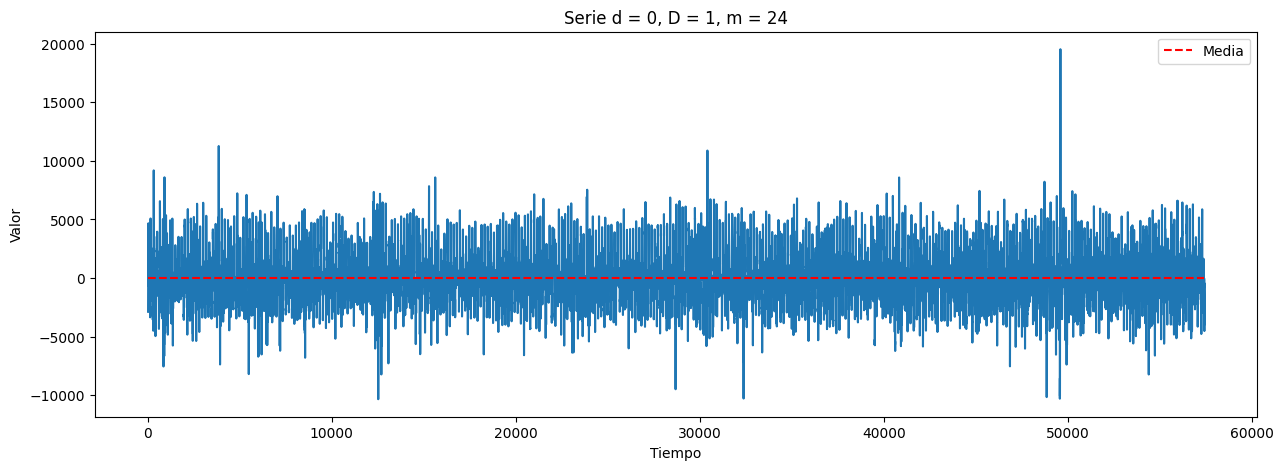

In [5]:
prueba_diferenciacion(df['value'], d=0, D=1, m=24)

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


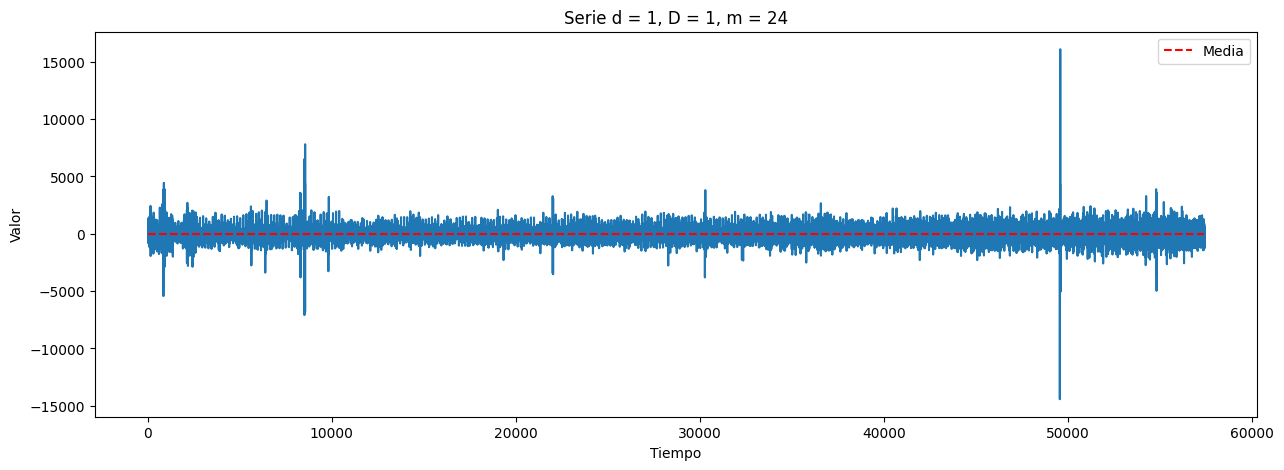

In [6]:
prueba_diferenciacion(df['value'], d=1, D=1, m=24)

ya no era necesaria una diferenciación para **d = 1**, así que solamente se hará una diferenciación estaciónal para trabajar con **D = 1**

### Parámetros para SARIMA

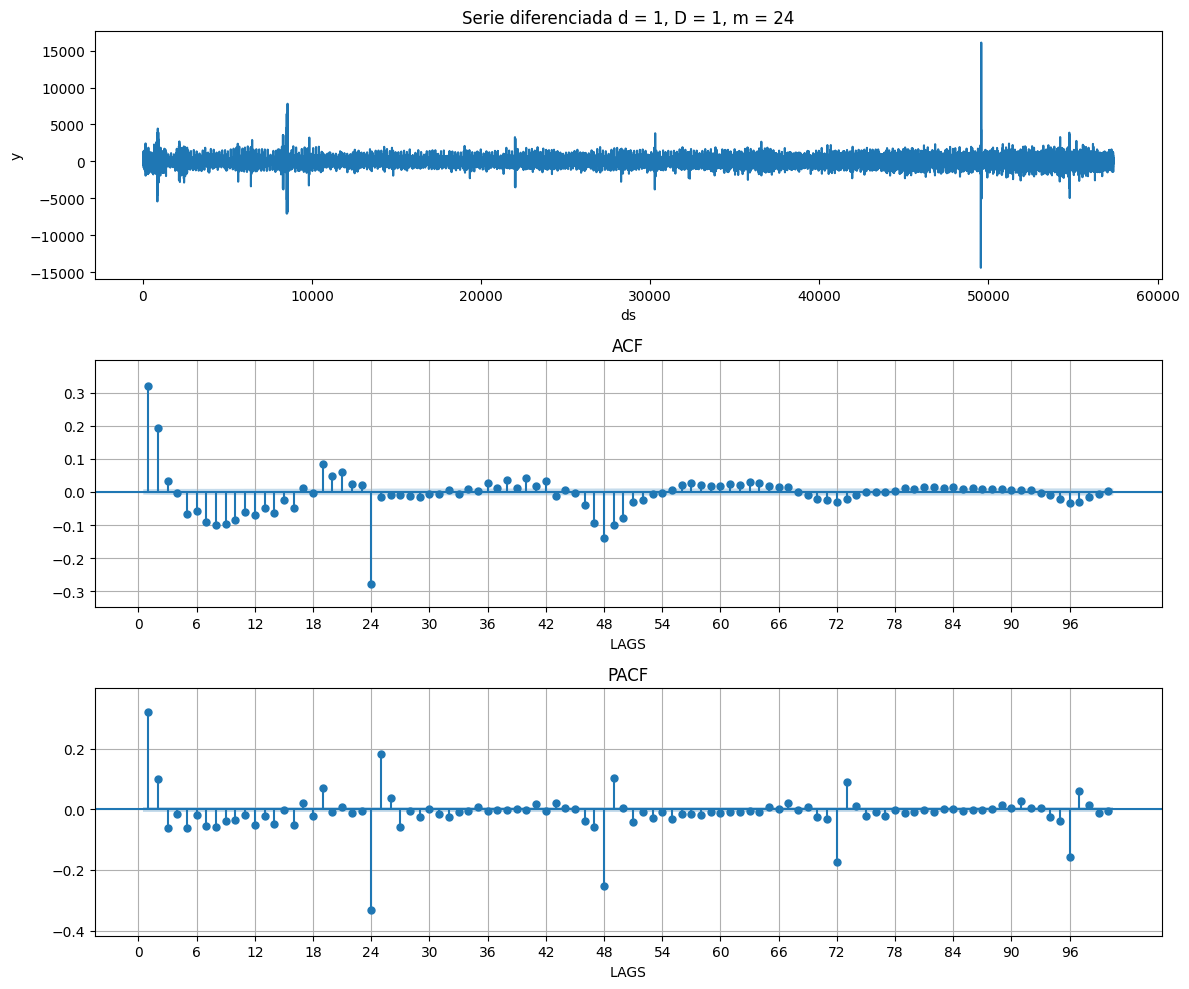

In [11]:
pacf_acf(df_train, 1, 1, 24)

Para la ACF:

* q: En el lag 1 y 2 podemos observar valores diferentes de 0 que podrían ser utilizados
* Q: En los múltiplos enteros de 24, encontramos que los valores de 1 y tal vez el 2 se pueden encontrar buenas opciones

Para la PACF

* p: El primer componente parece ser el indicado a usar como parámetro, usaremos 1 y 2
* P: En múltiplos de 24 se podría usar la opción 1 y 2, pero posteriormente no hay una caída abrupta en posteriores, así que se descarta este hiperparámetro

### Selección del mejor modelo SARIMA

In [13]:
ps, d, qs = [1, 2], 1, [1, 2]
P, D, Qs = 0, 1, [1, 2]

modelos = [ARIMA(order=(p, d, q), seasonal_order=(P, D, Q), season_length=24, alias=f'ARIMA({p},{d},{q})({P},{D},{Q})_24', include_constant=False) for p in ps for q in qs for Q in Qs] 

sf = StatsForecast(
    models = modelos,
    freq = 'h',
    n_jobs = -1
)

print(f'Se crearon {len(modelos)} modelos')
modelos

Se crearon 8 modelos


[ARIMA(1,1,1)(0,1,1)_24,
 ARIMA(1,1,1)(0,1,2)_24,
 ARIMA(1,1,2)(0,1,1)_24,
 ARIMA(1,1,2)(0,1,2)_24,
 ARIMA(2,1,1)(0,1,1)_24,
 ARIMA(2,1,1)(0,1,2)_24,
 ARIMA(2,1,2)(0,1,1)_24,
 ARIMA(2,1,2)(0,1,2)_24]